In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [2]:
PROJECT_ROOT = ".."

RAW_DATA_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "fer2013.csv")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Raw data path:", RAW_DATA_PATH)
print("Processed directory:", PROCESSED_DIR)
print("Figures directory:", FIGURES_DIR)

Raw data path: ../data/raw/fer2013.csv
Processed directory: ../data/processed
Figures directory: ../figures


In [3]:
df = pd.read_csv(RAW_DATA_PATH)

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns)

Dataset shape: (35887, 3)
   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training
Index(['emotion', 'pixels', 'Usage'], dtype='object')


In [4]:
EMOTIONS = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

df["label"] = df["emotion"].map(EMOTIONS)

df.head()

,emotion,pixels,Usage,label
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training,Angry
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training,Angry
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training,Fear
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training,Sad
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training,Neutral


In [5]:
df["Usage"].value_counts()

Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64

In [6]:
class_counts = df["label"].value_counts().reindex(EMOTIONS.values())

class_counts

label
Angry       4953
Disgust      547
Fear        5121
Happy       8989
Sad         6077
Surprise    4002
Neutral     6198
Name: count, dtype: int64

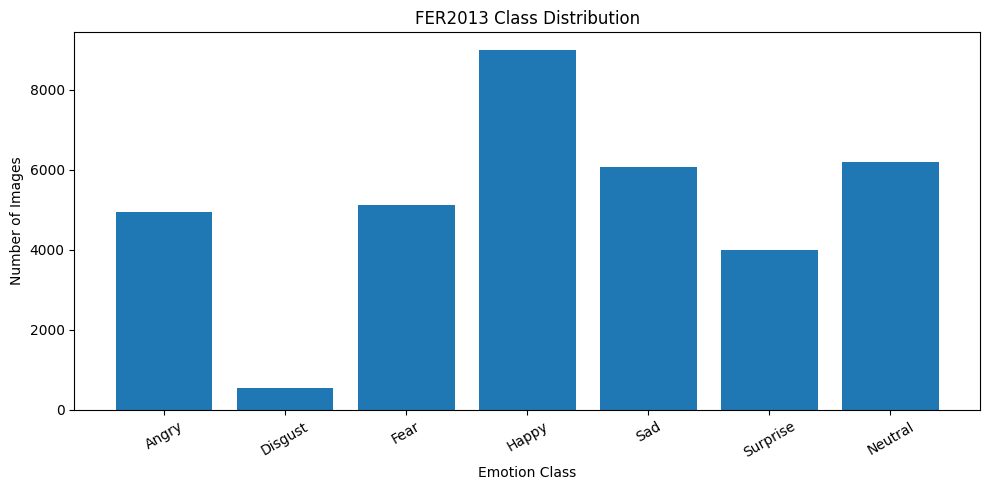

Saved to: ../figures/class_distribution.png


In [7]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.index, class_counts.values)

plt.title("FER2013 Class Distribution")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)

plt.tight_layout()

save_path = os.path.join(FIGURES_DIR, "class_distribution.png")
plt.savefig(save_path, dpi=150)
plt.show()

print("Saved to:", save_path)

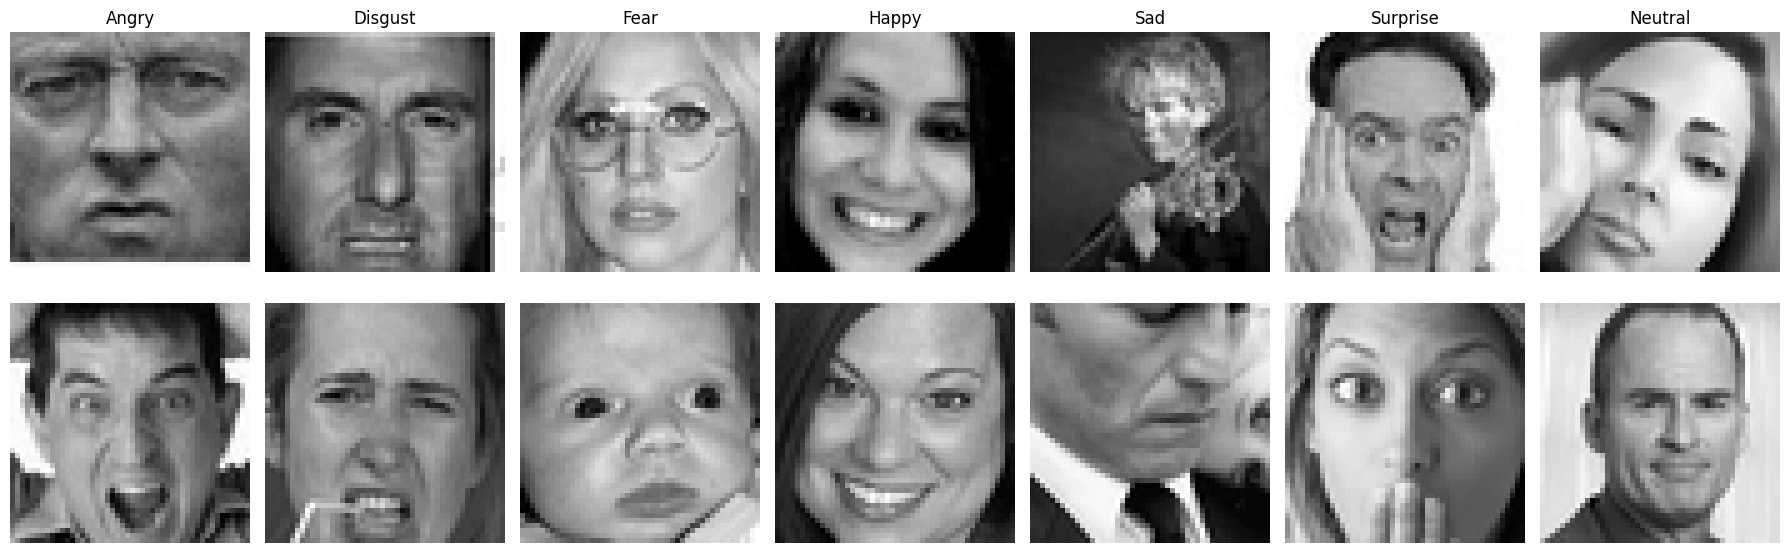

Saved to: ../figures/sample_images.png


In [8]:
#Visualise sample images per class
fig, axes = plt.subplots(2, 7, figsize=(18, 6))

for col, (code, name) in enumerate(EMOTIONS.items()):
    subset = df[df["emotion"] == code].sample(2, random_state=42)

    for row, (_, item) in enumerate(subset.iterrows()):
        pixels = np.array(item["pixels"].split(), dtype=np.uint8).reshape(48, 48)

        axes[row, col].imshow(pixels, cmap="gray")
        axes[row, col].axis("off")

        if row == 0:
            axes[row, col].set_title(name)

plt.tight_layout()

save_path = os.path.join(FIGURES_DIR, "sample_images.png")
plt.savefig(save_path, dpi=150)
plt.show()

print("Saved to:", save_path)

Flat pixel length: 2304
Image shape: (48, 48)


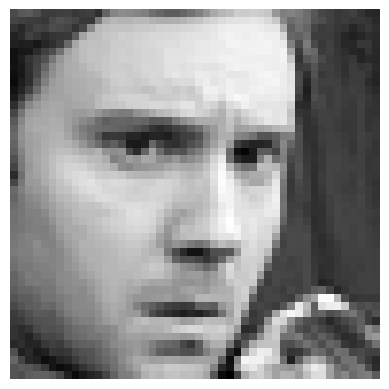

In [9]:
sample_pixels = np.array(df.iloc[0]["pixels"].split(), dtype=np.uint8)
print("Flat pixel length:", len(sample_pixels))

sample_img = sample_pixels.reshape(48, 48)
print("Image shape:", sample_img.shape)

plt.imshow(sample_img, cmap="gray")
plt.axis("off")
plt.show()

In [10]:
#Convert CSV rows into 224×224 RGB PNG images
def save_fer2013_images(df, output_root):
    for usage in df["Usage"].unique():
        subset = df[df["Usage"] == usage]

        print(f"Processing {usage}: {len(subset)} images")

        for idx, row in tqdm(subset.iterrows(), total=len(subset)):
            emotion_name = EMOTIONS[row["emotion"]]

            output_dir = os.path.join(output_root, usage, emotion_name)
            os.makedirs(output_dir, exist_ok=True)

            pixels = np.array(row["pixels"].split(), dtype=np.uint8).reshape(48, 48)

            img = Image.fromarray(pixels).convert("RGB")
            img = img.resize((224, 224))

            output_path = os.path.join(output_dir, f"{idx}.png")
            img.save(output_path)

    print("Done. Images saved to:", output_root)


save_fer2013_images(df, PROCESSED_DIR)

Processing Training: 28709 images


100%|████████████████████████████████████| 28709/28709 [03:07<00:00, 153.28it/s]


Processing PublicTest: 3589 images


100%|██████████████████████████████████████| 3589/3589 [00:23<00:00, 154.08it/s]


Processing PrivateTest: 3589 images


100%|██████████████████████████████████████| 3589/3589 [00:23<00:00, 154.03it/s]

Done. Images saved to: ../data/processed


In [11]:
for usage in ["Training", "PublicTest", "PrivateTest"]:
    print("\n", usage)

    for emotion in EMOTIONS.values():
        folder = os.path.join(PROCESSED_DIR, usage, emotion)

        if os.path.exists(folder):
            count = len(os.listdir(folder))
            print(f"{emotion}: {count}")
        else:
            print(f"{emotion}: folder missing")


 Training
Angry: 3995
Disgust: 436
Fear: 4097
Happy: 7215
Sad: 4830
Surprise: 3171
Neutral: 4965

 PublicTest
Angry: 467
Disgust: 56
Fear: 496
Happy: 895
Sad: 653
Surprise: 415
Neutral: 607

 PrivateTest
Angry: 491
Disgust: 55
Fear: 528
Happy: 879
Sad: 594
Surprise: 416
Neutral: 626


In [12]:
counts_table = (
    df.groupby(["Usage", "label"])
    .size()
    .reset_index(name="count")
)

counts_table_path = os.path.join(FIGURES_DIR, "fer2013_class_counts.csv")
counts_table.to_csv(counts_table_path, index=False)

counts_table

,Usage,label,count
0,PrivateTest,Angry,491
1,PrivateTest,Disgust,55
2,PrivateTest,Fear,528
3,PrivateTest,Happy,879
4,PrivateTest,Neutral,626
5,PrivateTest,Sad,594
6,PrivateTest,Surprise,416
7,PublicTest,Angry,467
8,PublicTest,Disgust,56
9,PublicTest,Fear,496
